# Phase 1: Synthetic Tasks — Hidden-Layer Perturbation Results

This notebook visualises the results of the Phase 1 synthetic experiments.  
At test time, a fraction **f** of hidden-layer spikes are replaced with random spikes (preserving spike count per neuron).  
- **f = 0**: hidden output untouched (full temporal code available).  
- **f = 1**: all temporal structure destroyed (rate-only internal signal).

Two model variants are compared:
- **Learnable Tau** — baseline SNN with learnable membrane time constants only.
- **Tau + Delay** — SNN with both learnable time constants and learnable axonal delays.

In [3]:
import json
import pathlib
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---------- global style ----------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

BASE = pathlib.Path(".")  # notebook lives in code/synthetic/

## ISI & CCISI - Accuracy vs Hidden-Layer Perturbation

Both ISI and CCISI tasks encode class information purely in spike timing.  
This plot shows how accuracy degrades as hidden-layer temporal structure is progressively destroyed.  
The dashed **FR Only Baseline** line marks the accuracy of a rate-only model (f = 1 on the worse-performing variant), giving a lower-bound reference.

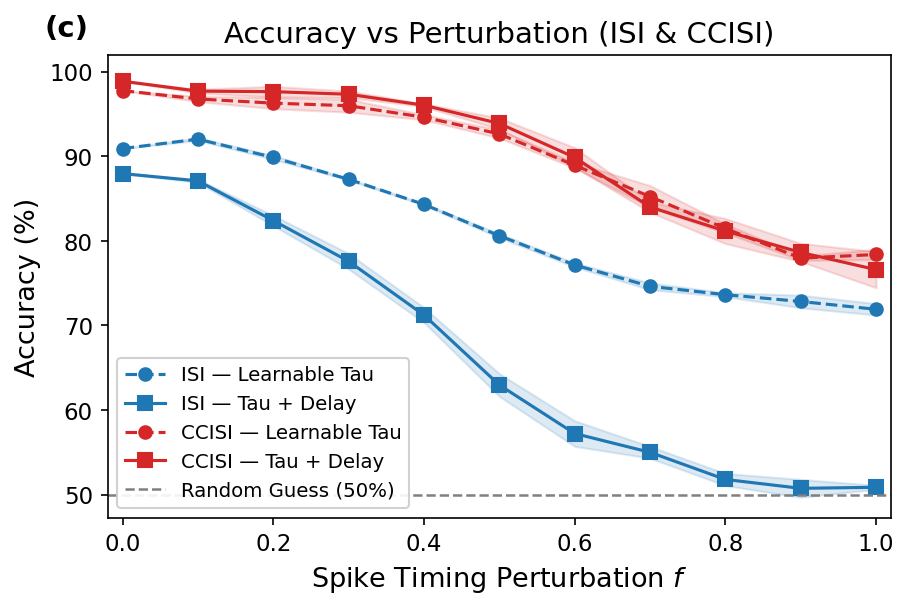

In [4]:
def load_results(path: pathlib.Path) -> dict:
    """Load a perturbation results JSON and return (f_values, means, stds)."""
    with open(path) as fh:
        raw = json.load(fh)
    f_vals = sorted(float(k) for k in raw)
    means = np.array([raw[str(f) if str(f) in raw else f"{f:.1f}"]["mean"] for f in f_vals]) * 100
    stds = np.array([raw[str(f) if str(f) in raw else f"{f:.1f}"]["std"] for f in f_vals]) * 100
    return f_vals, means, stds


# --- load ISI results ---
isi_tau_f, isi_tau_mean, isi_tau_std = load_results(BASE / "isi/log/isi_tau_hidden_perturbation_results.json")
isi_del_f, isi_del_mean, isi_del_std = load_results(BASE / "isi/log/isi_delay_hidden_perturbation_results.json")

# --- load CCISI results ---
cc_tau_f, cc_tau_mean, cc_tau_std = load_results(BASE / "ccisi/log/ccisi_tau_hidden_perturbation_results.json")
cc_del_f, cc_del_mean, cc_del_std = load_results(BASE / "ccisi/log/ccisi_delay_hidden_perturbation_results.json")

# --- FR-only baseline: worst f=1 accuracy across all four curves ---
#fr_baseline = min(isi_tau_mean[-1], isi_del_mean[-1], cc_tau_mean[-1], cc_del_mean[-1])
guess_baseline = 50

# --- colours matching the reference image ---
BLUE = "#1f77b4"
RED = "#d62728"

fig, ax = plt.subplots(figsize=(6.2, 4.2))

# ISI curves (blue)
ax.plot(isi_tau_f, isi_tau_mean, "o--", color=BLUE, markersize=6, label="ISI — Learnable Tau")
ax.fill_between(isi_tau_f, isi_tau_mean - isi_tau_std, isi_tau_mean + isi_tau_std, color=BLUE, alpha=0.15)

ax.plot(isi_del_f, isi_del_mean, "s-", color=BLUE, markersize=7, label="ISI — Tau + Delay")
ax.fill_between(isi_del_f, isi_del_mean - isi_del_std, isi_del_mean + isi_del_std, color=BLUE, alpha=0.15)

# CCISI curves (red)
ax.plot(cc_tau_f, cc_tau_mean, "o--", color=RED, markersize=6, label="CCISI — Learnable Tau")
ax.fill_between(cc_tau_f, cc_tau_mean - cc_tau_std, cc_tau_mean + cc_tau_std, color=RED, alpha=0.15)

ax.plot(cc_del_f, cc_del_mean, "s-", color=RED, markersize=7, label="CCISI — Tau + Delay")
ax.fill_between(cc_del_f, cc_del_mean - cc_del_std, cc_del_mean + cc_del_std, color=RED, alpha=0.15)

# FR-only baseline
#ax.axhline(fr_baseline, color="gray", linestyle="--", linewidth=1.2, label="FR Only Baseline")

# Random guess baseline
ax.axhline(guess_baseline, color="gray", linestyle="--", linewidth=1.2, label="Random Guess (50%)")

# --- axes & labels ---
ax.set_xlabel("Spike Timing Perturbation $f$")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Perturbation (ISI & CCISI)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(None, 102)
ax.legend(loc="lower left", framealpha=0.9)

# subplot label like the reference image
ax.text(-0.08, 1.04, "(c)", transform=ax.transAxes, fontsize=14, fontweight="bold")

fig.tight_layout()
#plt.savefig("isi_ccisi_hidden_perturbation.png", dpi=300, bbox_inches="tight")
plt.show()